## Imports

In [1]:
from utils.data_prepocessing import _ensure_monthly_index_and_align_exog, plot_forecaster_feature_importance
from utils.constants import (
CATEGORY_MAP,
CAT_MAP_ENCODING,
CATEGORY_MAP_CHEMICALS,
CATEGORY_MAP_CHEMICALS_ENCODING,
BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    transform_and_plot_trend_for_cat,
    get_best_result_for_runs,
    plot_best_mape_predictors,
    aggregate_metrics_result,
    extrapolate_results,
    plot_known_feature_value,
    extrapolate_results_to_single_ts
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


---
## Data prepocessing

In [2]:
directory = "Sber-Conditional/Data/"  # set directory path
d = {}
formed = {}

for i, entry in enumerate(os.scandir(directory)):  
    if entry.is_file() and entry.name.endswith('.xlsx'):  # check if it's a file
        # print(entry.name)
        d[entry.name] = pd.read_excel(f"{directory}{entry.name}")
    elif entry.is_file() and entry.name.endswith('.csv'):
        formed[entry.name] = pd.read_csv(f"{directory}{entry.name}")

global_macros = d["global_macro.xlsx"]
apk_nona = formed["apk_nona.csv"]

chemicals_nona = formed["chemicals_nona.csv"]
chemicals_nona["Date"] = pd.to_datetime(chemicals_nona["Date"])
chemicals_nona = chemicals_nona.set_index('Date')

global_macros = global_macros.drop(columns=["Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1"])

apk_nona["Date"] = apk_nona["Unnamed: 0"]
apk_nona["Date"] = pd.to_datetime(apk_nona["Date"])

global_macros = global_macros.iloc[3:][::-1].reset_index(drop=True)
global_macros = global_macros.drop(columns=["Date"])
global_macros.index = apk_nona["Date"]

apk_nona = apk_nona.set_index('Date')


assert global_macros.shape[0] == apk_nona.shape[0]


apk_nona_en, global_macros_en = _ensure_monthly_index_and_align_exog(apk_nona, global_macros)
chemicals_nona_en, global_macros_en_chemicals = _ensure_monthly_index_and_align_exog(chemicals_nona[chemicals_nona.index<=global_macros.index.max()],
                                                                                     global_macros[global_macros.index>=chemicals_nona.index.min()])
global_macros_en.columns = list(map(lambda x: " ".join(x.split()), list(global_macros_en.columns)))  # убираем табы

apk_nona_en_rol = transform_and_plot_trend_for_cat(apk_nona_en, 12, norm_method="index", plot_graphics=False)
chemicals_nona_en_rol = transform_and_plot_trend_for_cat(chemicals_nona_en, 12, norm_method="index", features_to_cat=CATEGORY_MAP_CHEMICALS, plot_graphics=False)

macro_data = global_macros_en[global_macros_en.index >= apk_nona_en_rol.dropna().index[0]]

---
## Global parameters setting

In [3]:
PREDICTION_HORIZON_APK = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_APK = 12
PREDICTION_HORIZON_CHEMICALS = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS = 12
PREDICTOR_LAG_APK = 12
PREDICTOR_LAG_CHEMICALS = 12
FUTURE_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK)
BACKTEST_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK*2)
BACKTEST_DATE_CHEMICALS = chemicals_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_CHEMICALS*2)
## Parameters with known future values
FUTURE_FORECASTER_TS_NAME = "Ключевая ставка, годовых"
FUTURE_FORECASTER_TS_VALUES = [12.2]*(PREDICTION_HORIZON_APK)
if not FUTURE_FORECASTER_TS_VALUES:
    for _ in range(max(PREDICTION_HORIZON_APK, PREDICTION_HORIZON_CHEMICALS)):
        tmp = input()
        FUTURE_FORECASTER_TS_VALUES.append(float(tmp))

## Directories to save naive results
NAIVE_PREDICTOR_RESULT_PATH_APK = f"darts_result_tables_naive_{PREDICTION_HORIZON_APK}"
NAIVE_PREDICTOR_RESULT_PATH_CHEMICALS = f"darts_result_tables_naive_chemicals_{NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS}"
## Directories to save naive results

TARGET_COL_SUFFIX = "_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal", "naivedrift", "naivemean", "naivemovingaverage"] = "tftmodel"
TS_TO_PREDICT = "Кукуруза"

train_end = BACKTEST_DATE_APK
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")

---
## Known TS future

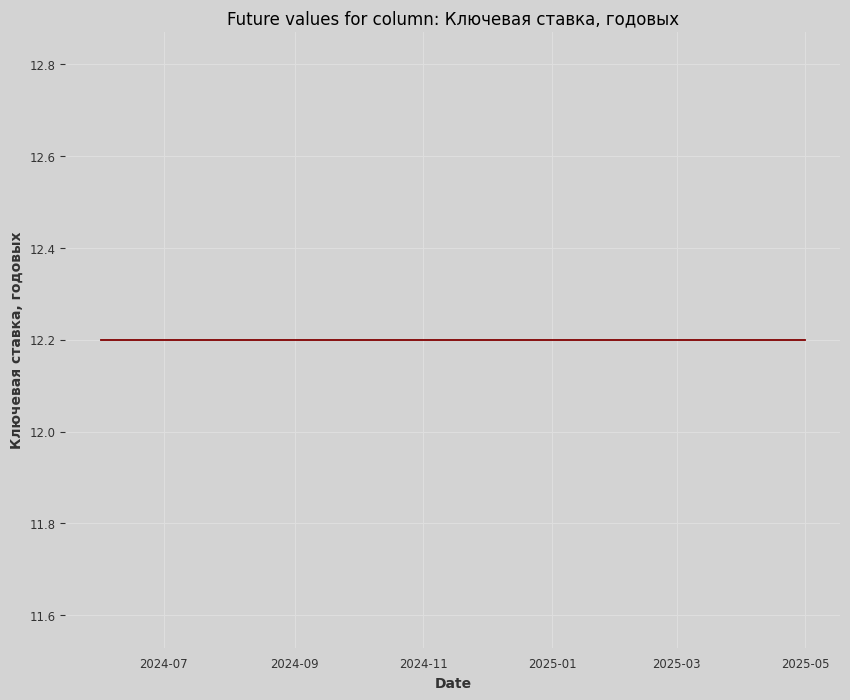

In [4]:
plot_known_feature_value(FUTURE_FORECASTER_TS_VALUES,
                         FUTURE_FORECASTER_TS_NAME,
                         pd.date_range(start=FUTURE_DATE_APK + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS"))

---
## APK

### Forecasting clusers

C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_cov_df = future_cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollec

Training: |                                                                              | 0/? [00:00<?, ?it/s…

`Trainer.fit` stopped: `max_epochs=100` reached.
C:\Users\omirz\AppData\Local\Temp\ipykernel_46808\1793957445.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                                                            | 0/? [00:00<?, ?it/s…

C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_cov_df = future_cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollec

...

Predicting: |                                                                            | 0/? [00:00<?, ?it/s…

C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
C:\Users\omirz\Desktop\Sber_conditional\utils\cluster_forecast.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_cov_df = future_cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollec

Training: |                                                                              | 0/? [00:00<?, ?it/s…

`Trainer.fit` stopped: `max_epochs=100` reached.
C:\Users\omirz\AppData\Local\Temp\ipykernel_46808\1793957445.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                                                            | 0/? [00:00<?, ?it/s…

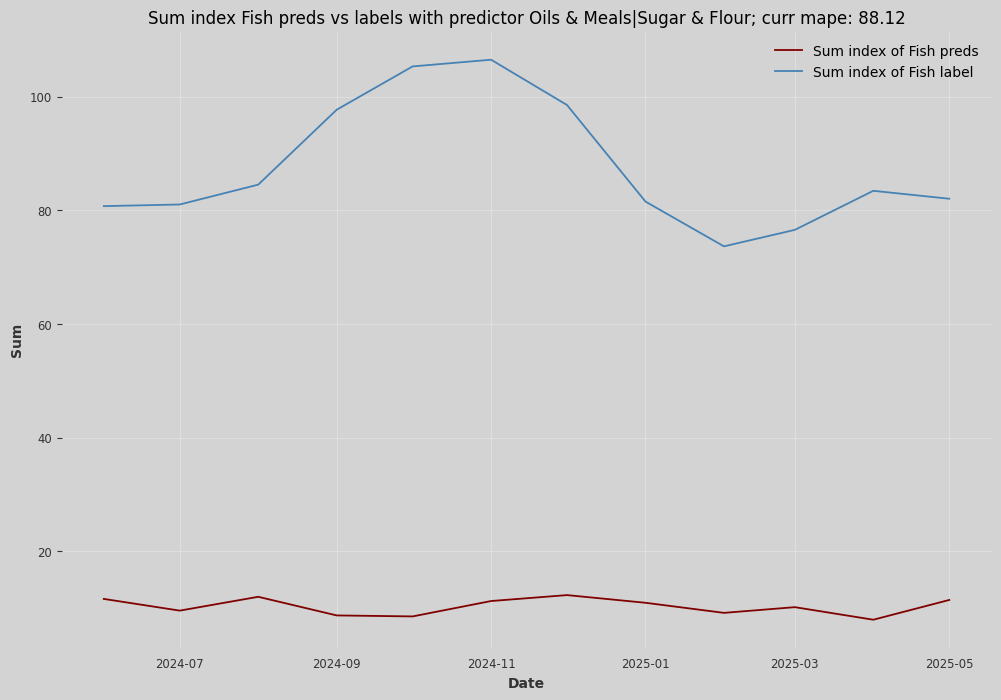

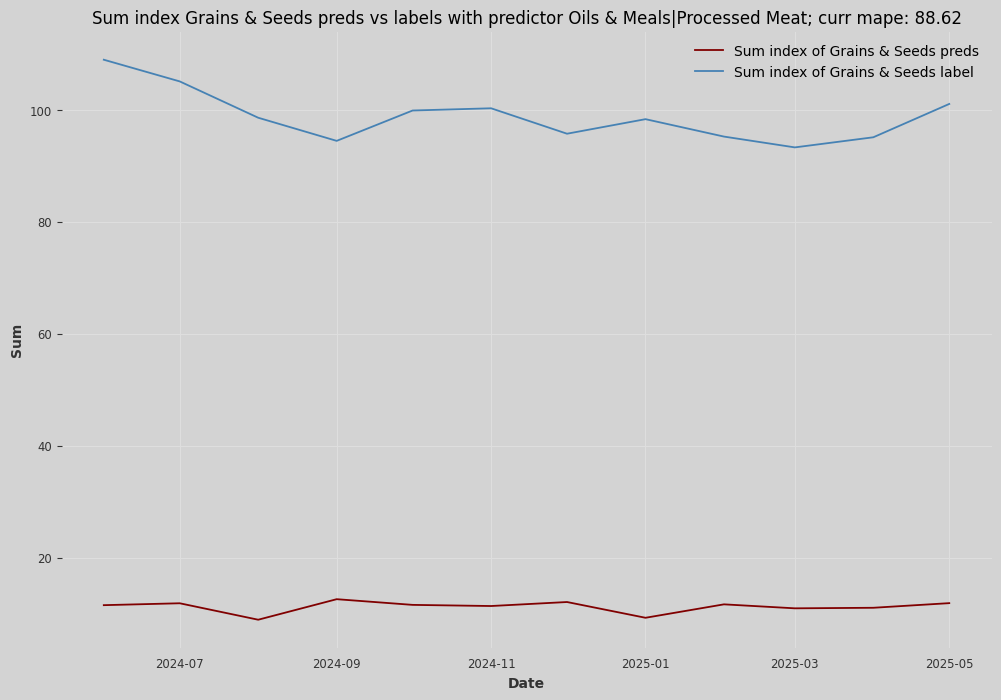

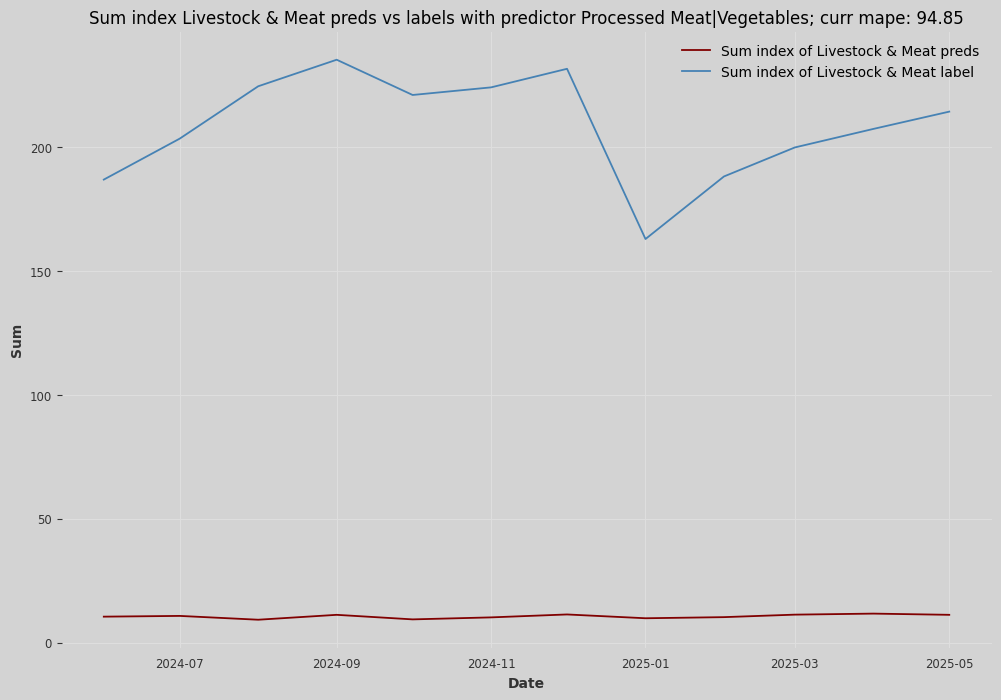

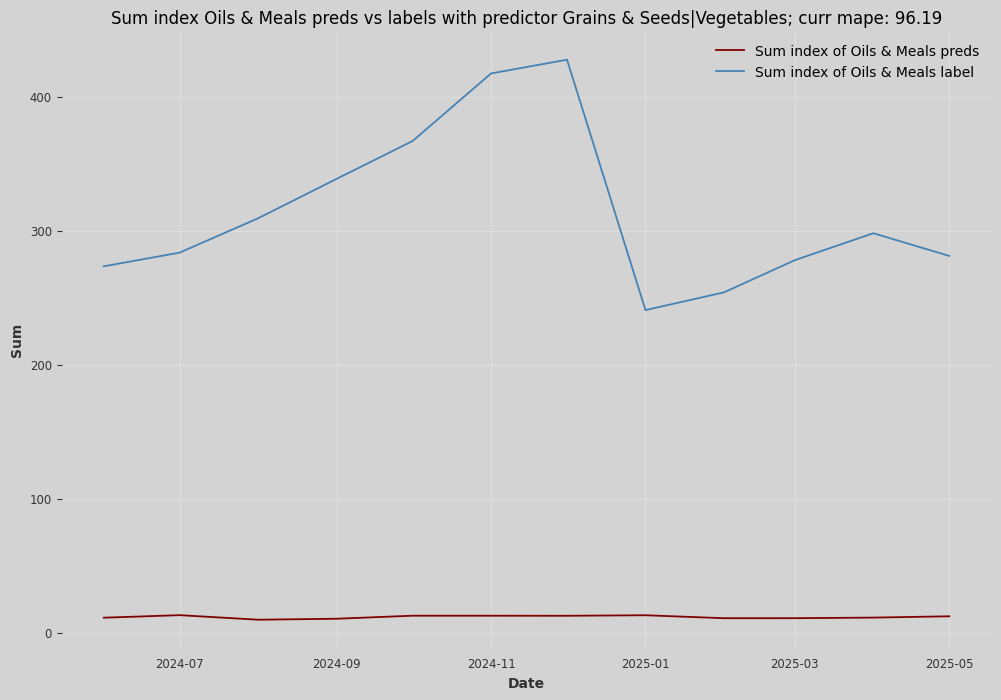

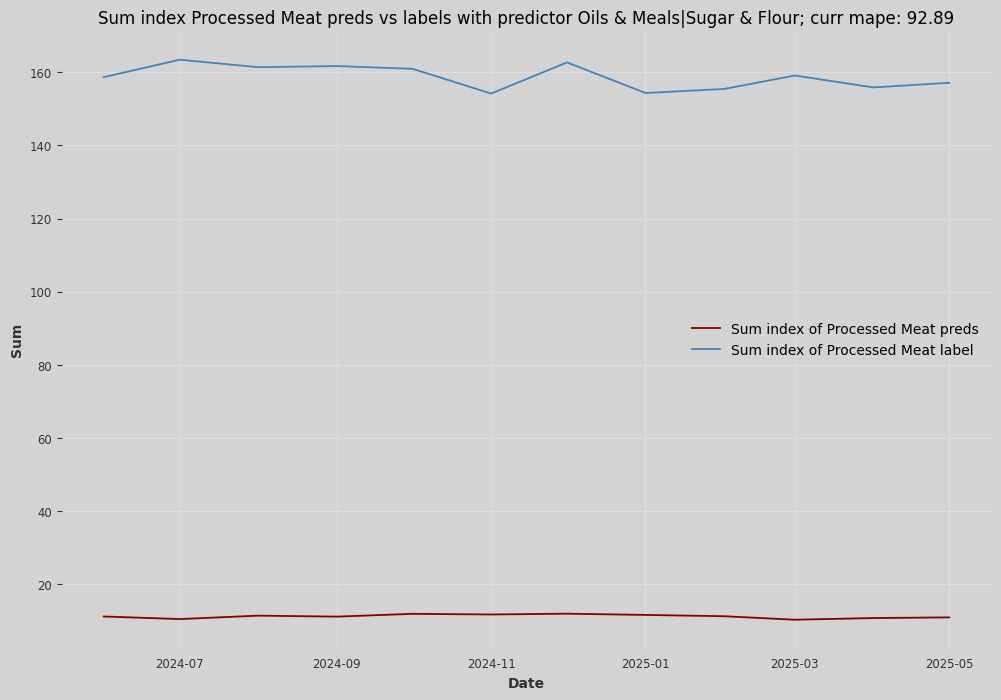

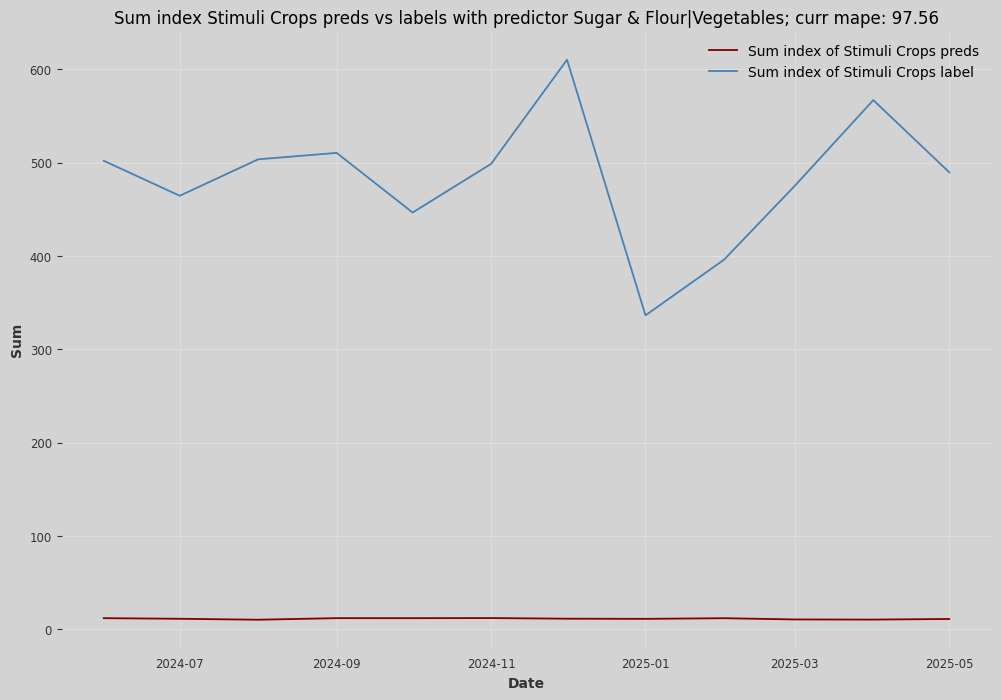

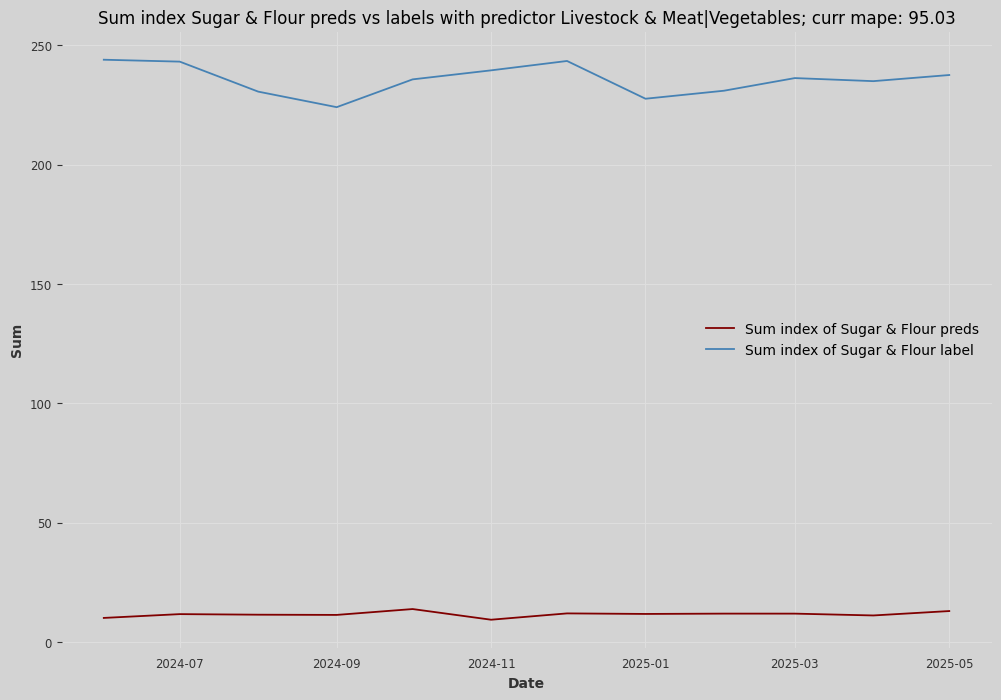

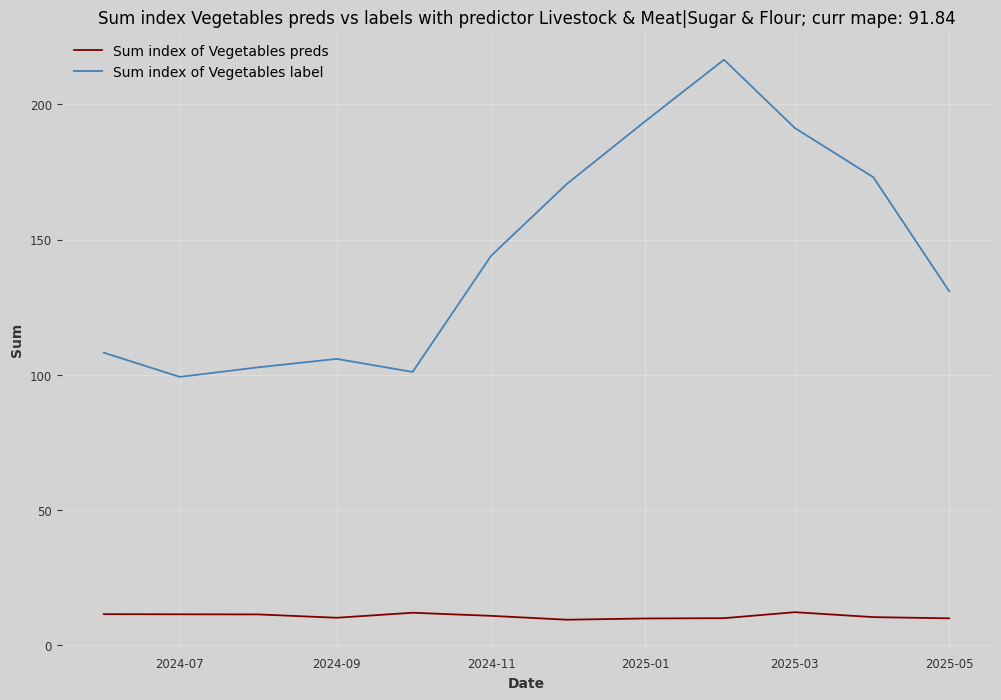

In [5]:
all_clusters = sorted(set(CATEGORY_MAP.values()))
forecasts_for_cluster: dict[str, Type[TimeSeries]] = {}
forecasters_for_cluster: dict[str, Type[ClusterForecaster]] = {}
for target_cat in all_clusters:
    predictors_lst:list[str] = BEST_PREDICTORS_FOR_INDEX.get(target_cat)
    past_data_for_train = apk_nona_en_rol.dropna()[apk_nona_en_rol.dropna().index<=past_idx[-1]]
    macro_data_for_train = macro_data[macro_data.index<=past_idx[-1]]
    forecaster = ClusterForecaster(
        cluster_data=past_data_for_train,
        macro_data=macro_data_for_train,
        category_map=CATEGORY_MAP,
        freq="M",
        target_col_suffix="_sum",
        dir_to_save_plots="darts_result_pairs_new",
        dir_to_save_tables="darts_result_tables_pairs_new",
        future_macro_col=FUTURE_FORECASTER_TS_NAME
    )
    forecaster.train(target_cat, predictors_lst, model_type=MODEL_NAME_FOR_FORECASTER)
    cov_past = pd.DataFrame(index=past_idx)
    cov_past = pd.concat([cov_past, macro_data], axis=1)
    if predictors_lst:
        for additional_cluster in predictors_lst:
            all_add = apk_nona_en_rol.dropna()[f"{additional_cluster}{TARGET_COL_SUFFIX}"].shift(1)
            cov_past[f"{additional_cluster}_lag1"] = all_add.reindex(past_idx)
    cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")

    cov_future = pd.concat([macro_data[FUTURE_FORECASTER_TS_NAME][past_idx],
                              pd.DataFrame(FUTURE_FORECASTER_TS_VALUES,
                                           index=future_idx,
                                           columns=[FUTURE_FORECASTER_TS_NAME])])

    preds = forecaster.forecast(PREDICTION_HORIZON_APK,
                        cov_past,
                        cov_future)
    forecasters_for_cluster[target_cat] = forecaster
    forecasts_for_cluster[target_cat] = preds
    target_s = apk_nona_en_rol.dropna()[apk_nona_en_rol.dropna().index >= pd.to_datetime(future_idx[0])][f"{target_cat}_sum"]
    pred_ts, actual_ts, metrics = forecaster.plot_and_return_data_backtest(TimeSeries.from_series(target_s),
                                                                           preds,
                                                                           target_cat,
                                                                           future_idx,
                                                                           predictors_lst)

### Forecasting specific TS

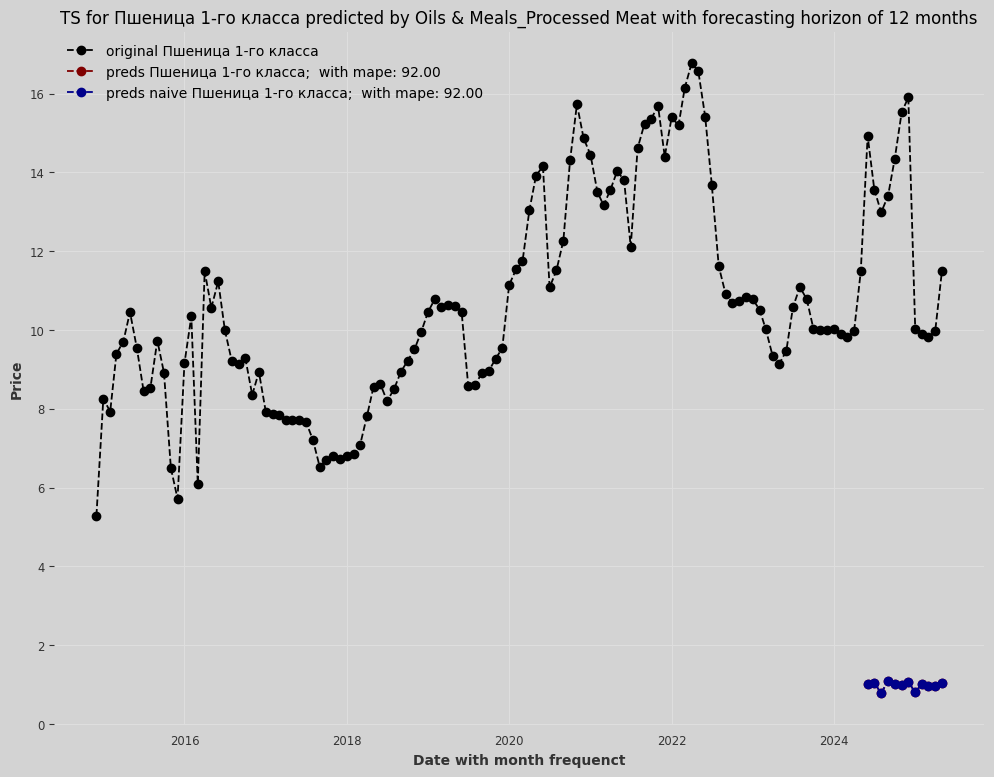

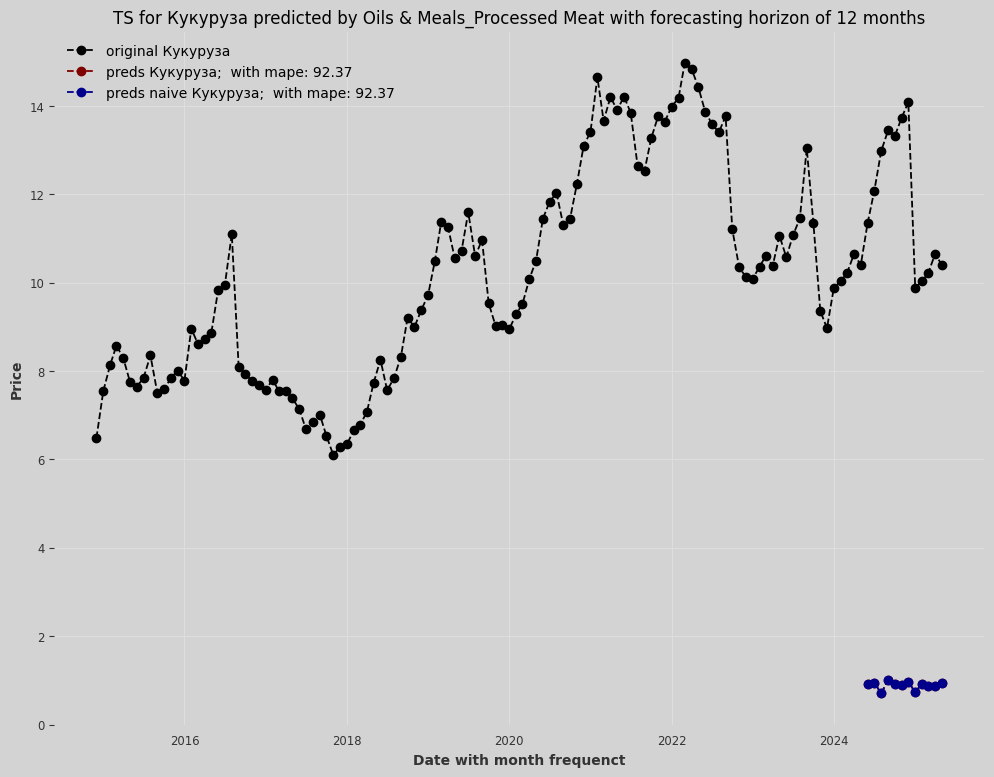

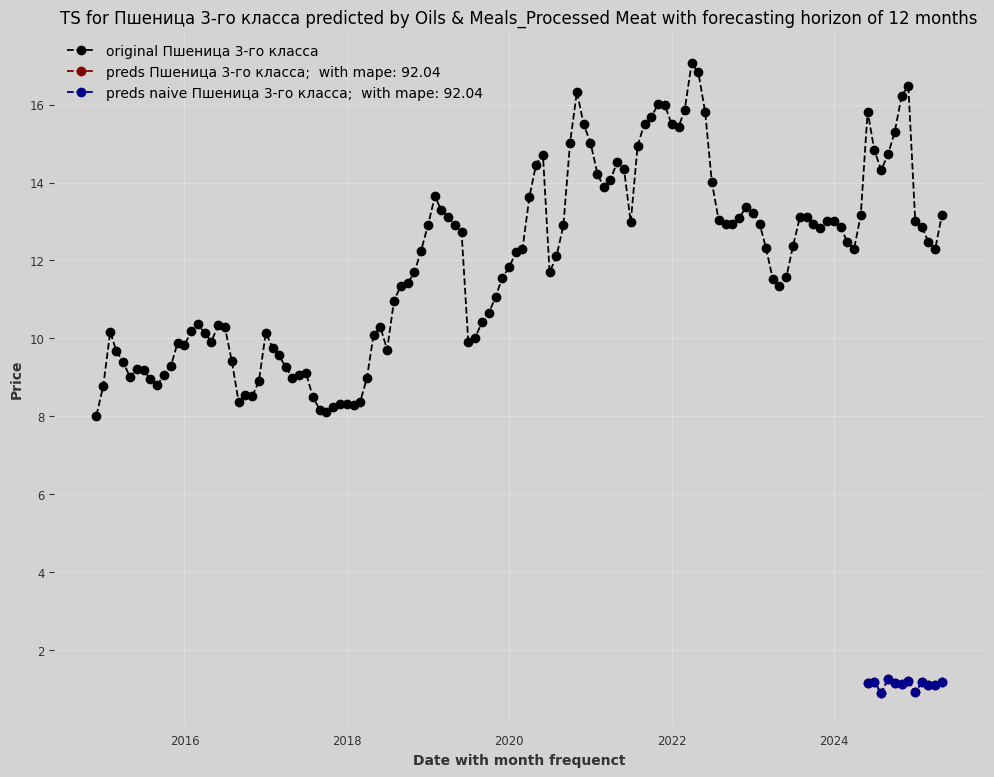

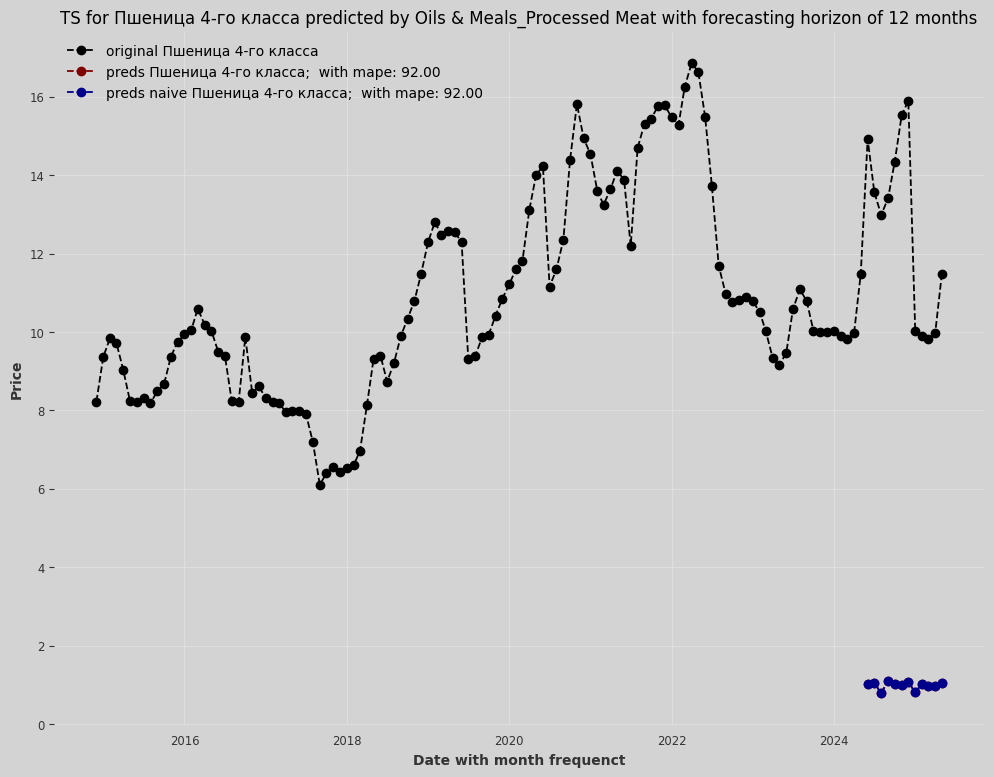

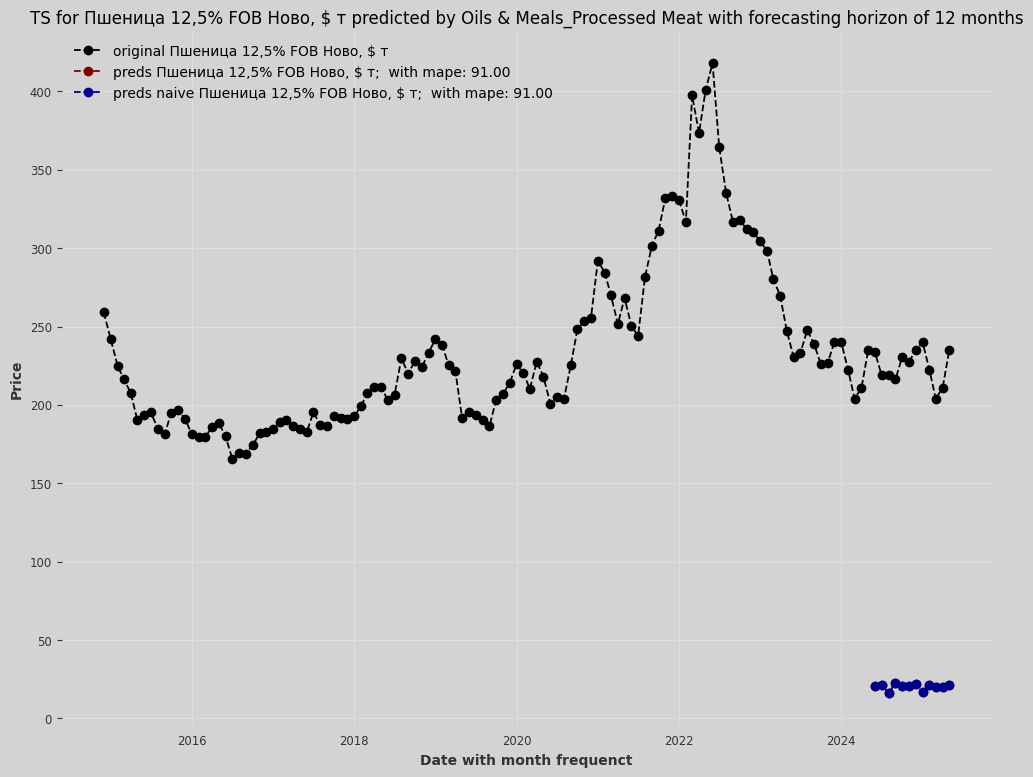

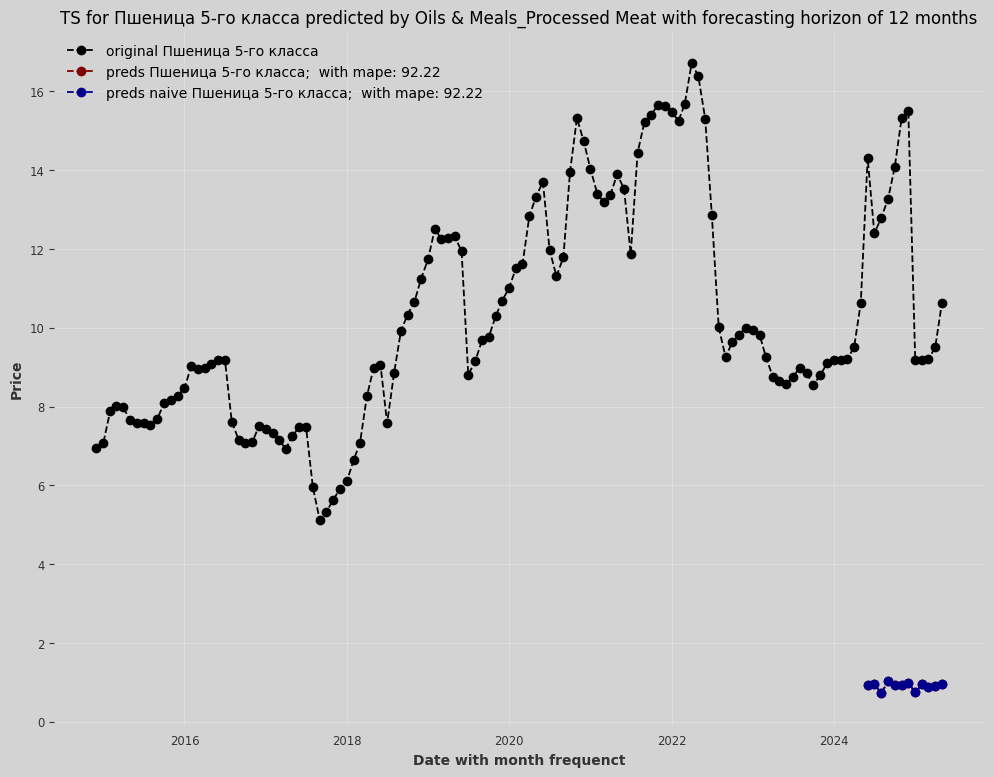

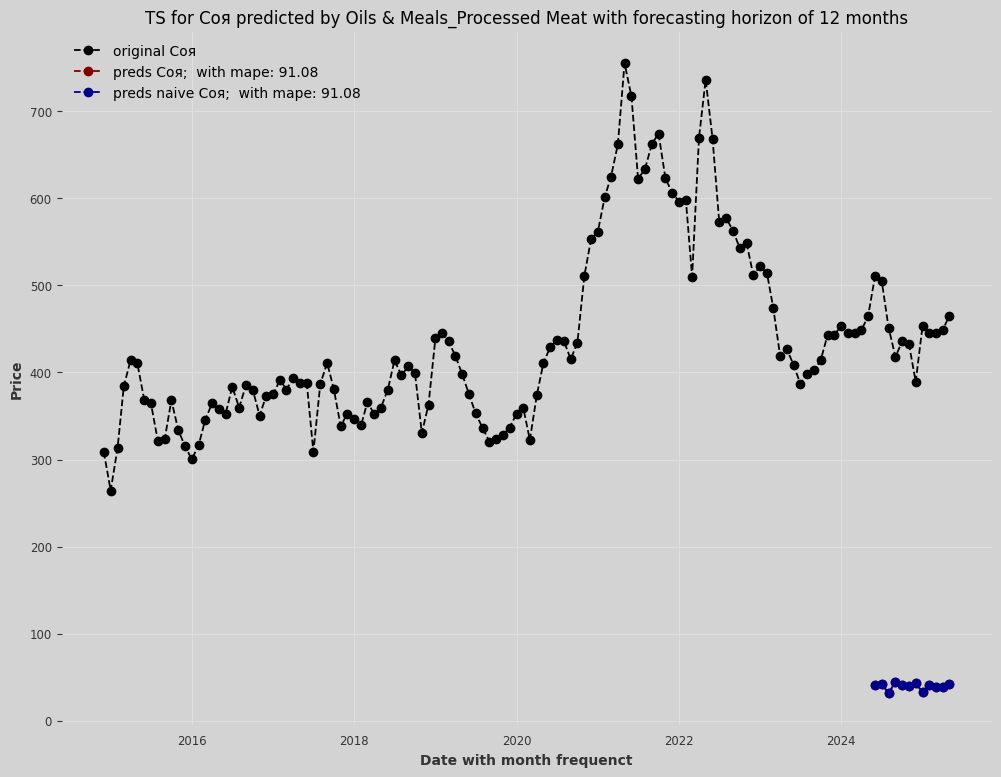

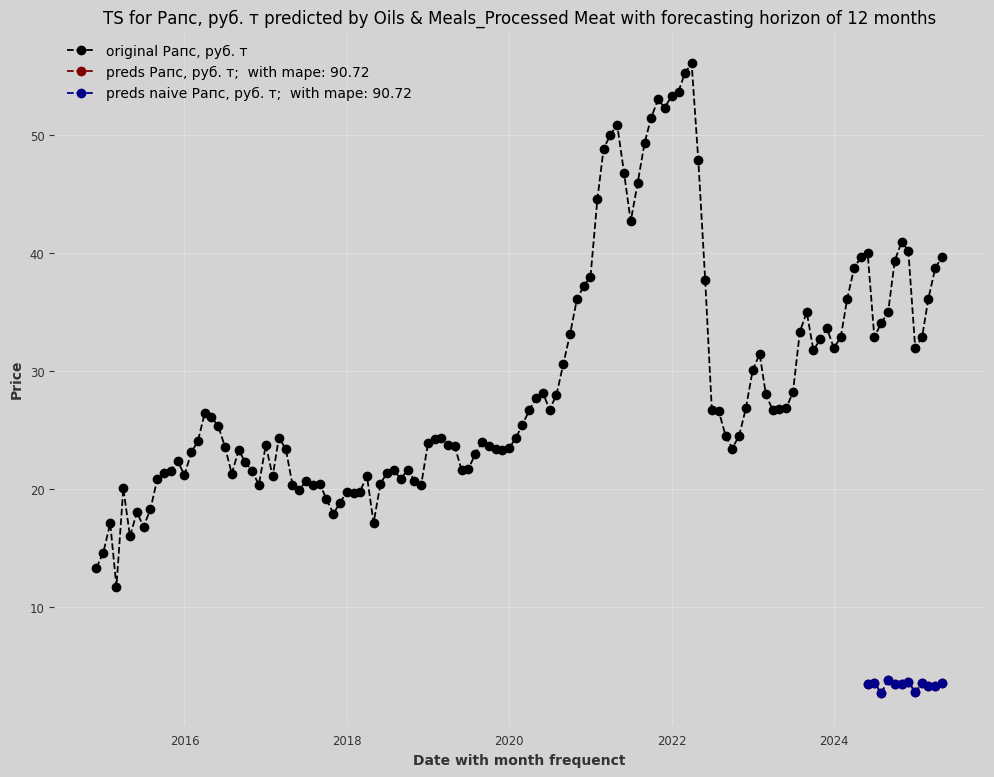

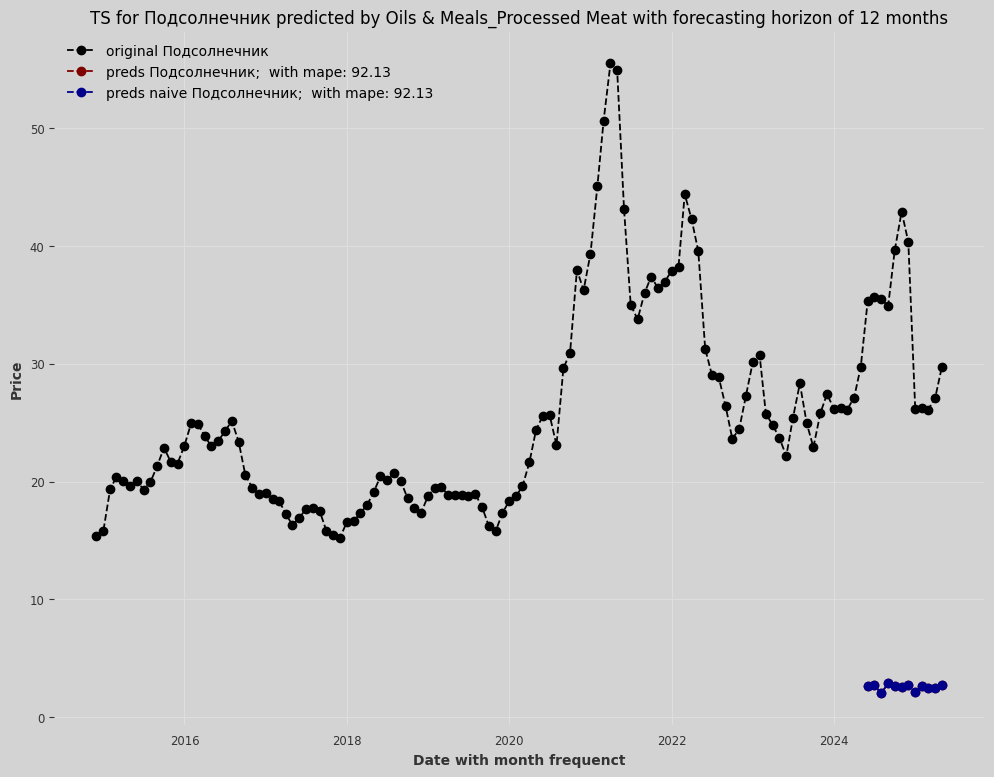

In [6]:
extrapolate_results_to_single_ts(TS_TO_PREDICT,
                    apk_nona_en_rol.dropna(),
                    "darts_result_tables_pairs_new",
                    past_idx[-1],
                    f"tft_{TS_TO_PREDICT}.csv",
                    output_dir_ts=f"tft_{TS_TO_PREDICT}"
                    )